In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import operator
import warnings
import time

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge,Lasso,RidgeCV, LassoCV
from sklearn import metrics
from sklearn.model_selection import StratifiedKFold, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn import *
import xgboost as xgb
from xgboost.sklearn import XGBRegressor

%matplotlib inline
warnings.filterwarnings("ignore")
pd.options.display.max_columns = 200

### Part 1 - The Lasso and Boosting for Regression

#### (a) Use the first 1495 rows of data as the training set and the rest as the test set

In [2]:
# Read communities and crime dataset
communities = pd.read_csv("./communities.csv",header=None)
print(communities.shape)
communities.head()

(1994, 128)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127
0,8,?,?,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,0.29,0.32,0.20,1.0,0.37,0.72,0.34,0.60,0.29,0.15,0.43,0.39,0.40,0.39,0.32,0.27,0.27,0.36,0.41,0.08,0.19,0.10,0.18,0.48,0.27,0.68,0.23,0.41,0.25,0.52,0.68,0.40,0.75,0.75,0.35,0.55,0.59,0.61,0.56,0.74,0.76,0.04,0.14,0.03,0.24,0.27,0.37,0.39,0.07,0.07,0.08,0.08,0.89,0.06,0.14,0.13,0.33,0.39,0.28,0.55,0.09,0.51,0.5,0.21,0.71,0.52,0.05,0.26,0.65,0.14,0.06,0.22,0.19,0.18,0.36,0.35,0.38,0.34,0.38,0.46,0.25,0.04,0.0,0.12,0.42,0.50,0.51,0.64,0.03,0.13,0.96,0.17,0.06,0.18,0.44,0.13,0.94,0.93,0.03,0.07,0.1,0.07,0.02,0.57,0.29,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
1,53,?,?,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,0.35,0.27,0.02,1.0,0.31,0.72,0.11,0.45,0.25,0.29,0.39,0.29,0.37,0.38,0.33,0.16,0.30,0.22,0.35,0.01,0.24,0.14,0.24,0.30,0.27,0.73,0.57,0.15,0.42,0.36,1.00,0.63,0.91,1.00,0.29,0.43,0.47,0.60,0.39,0.46,0.53,0.00,0.24,0.01,0.52,0.62,0.64,0.63,0.25,0.27,0.25,0.23,0.84,0.10,0.16,0.10,0.17,0.29,0.17,0.26,0.20,0.82,0.0,0.02,0.79,0.24,0.02,0.25,0.65,0.16,0.00,0.21,0.20,0.21,0.42,0.38,0.40,0.37,0.29,0.32,0.18,0.00,0.0,0.21,0.50,0.34,0.60,0.52,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,0.02,0.12,0.45,?,?,?,?,0.00,?,0.67
2,24,?,?,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,0.28,0.32,0.00,0.0,0.30,0.58,0.19,0.39,0.38,0.40,0.84,0.28,0.27,0.29,0.27,0.07,0.29,0.28,0.39,0.01,0.27,0.27,0.43,0.19,0.36,0.58,0.32,0.29,0.49,0.32,0.63,0.41,0.71,0.70,0.45,0.42,0.44,0.43,0.43,0.71,0.67,0.01,0.46,0.00,0.07,0.06,0.15,0.19,0.02,0.02,0.04,0.05,0.88,0.04,0.20,0.20,0.46,0.52,0.43,0.42,0.15,0.51,0.5,0.01,0.86,0.41,0.29,0.30,0.52,0.47,0.45,0.18,0.17,0.16,0.27,0.29,0.27,0.31,0.48,0.39,0.28,0.00,0.0,0.14,0.49,0.54,0.67,0.56,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,0.01,0.21,0.02,?,?,?,?,0.00,?,0.43
3,34,5,81440,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,0.34,0.21,0.06,1.0,0.58,0.89,0.21,0.43,0.36,0.20,0.82,0.51,0.36,0.40,0.39,0.16,0.25,0.36,0.44,0.01,0.10,0.09,0.25,0.31,0.33,0.71,0.36,0.45,0.37,0.39,0.34,0.45,0.49,0.44,0.75,0.65,0.54,0.83,0.65,0.85,0.86,0.03,0.33,0.02,0.11,0.20,0.30,0.31,0.05,0.08,0.11,0.11,0.81,0.08,0.56,0.62,0.85,0.77,1.00,0.94,0.12,0.01,0.5,0.01,0.97,0.96,0.60,0.47,0.52,0.11,0.11,0.24,0.21,0.19,0.75,0.70,0.77,0.89,0.63,0.51,0.47,0.00,0.0,0.19,0.30,0.73,0.64,0.65,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,0.02,0.39,0.28,?,?,?,?,0.00,?,0.12
4,42,95,6096,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,0.05,0.38,0.38,0.23,0.36,0.02,0.9,0.50,0.72,0.16,0.68,0.44,0.11,0.71,0.46,0.43,0.41,0.28,0.00,0.74,0.51,0.48,0.00,0.06,0.25,0.30,0.33,0.12,0.65,0.67,0.38,0.42,0.46,0.22,0.27,0.20,0.21,0.51,0.91,0.91,0.89,0.85,0.40,0.60,0.00,0.06,0.00,0.03,0.07,0.20,0.27,0.01,0.02,0.04,0.05,0.88,0.05,0.16,0.19,0.59,0.60,0.37,0.89,0.02,0.19,0.5,0.01,0.89,0.87,0.04,0.55,0.73,0.05,0.14,0.31,0.31,0.30,0.40,0.36,0.38,0.38,0.22,0.51,0.21,0.00,0.0,0.11,0.72,0.64,0.61,0.53,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,0.04,0.09,0.02,?,?,?,?,0.00,?,0.03


In [3]:
# Set attribute names to columns
attributes = []
count = 0
with open("./communities.names","r") as f:
    line = f.readline()
    if line.startswith("@attribute"):
        attributes.append(line.split(" ")[1])
        count += 1
    while line:
        line = f.readline()
        if line.startswith("@attribute"):
            attributes.append(line.split(" ")[1])
            count += 1        
            
communities.columns = attributes
communities.head()

,state,county,community,communityname,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,numbUrban,pctUrban,medIncome,pctWWage,pctWFarmSelf,pctWInvInc,pctWSocSec,pctWPubAsst,pctWRetire,medFamInc,perCapInc,whitePerCap,blackPerCap,indianPerCap,AsianPerCap,OtherPerCap,HispPerCap,NumUnderPov,PctPopUnderPov,PctLess9thGrade,PctNotHSGrad,PctBSorMore,PctUnemployed,PctEmploy,PctEmplManu,PctEmplProfServ,PctOccupManu,PctOccupMgmtProf,MalePctDivorce,MalePctNevMarr,FemalePctDiv,TotalPctDiv,PersPerFam,PctFam2Par,PctKids2Par,PctYoungKids2Par,PctTeen2Par,PctWorkMomYoungKids,PctWorkMom,NumIlleg,PctIlleg,NumImmig,PctImmigRecent,PctImmigRec5,PctImmigRec8,PctImmigRec10,PctRecentImmig,PctRecImmig5,PctRecImmig8,PctRecImmig10,PctSpeakEnglOnly,PctNotSpeakEnglWell,PctLargHouseFam,PctLargHouseOccup,PersPerOccupHous,PersPerOwnOccHous,PersPerRentOccHous,PctPersOwnOccup,PctPersDenseHous,PctHousLess3BR,MedNumBR,HousVacant,PctHousOccup,PctHousOwnOcc,PctVacantBoarded,PctVacMore6Mos,MedYrHousBuilt,PctHousNoPhone,PctWOFullPlumb,OwnOccLowQuart,OwnOccMedVal,OwnOccHiQuart,RentLowQ,RentMedian,RentHighQ,MedRent,MedRentPctHousInc,MedOwnCostPctInc,MedOwnCostPctIncNoMtg,NumInShelters,NumStreet,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LemasSwornFT,LemasSwFTPerPop,LemasSwFTFieldOps,LemasSwFTFieldPerPop,LemasTotalReq,LemasTotReqPerPop,PolicReqPerOffic,PolicPerPop,RacialMatchCommPol,PctPolicWhite,PctPolicBlack,PctPolicHisp,PctPolicAsian,PctPolicMinor,OfficAssgnDrugUnits,NumKindsDrugsSeiz,PolicAveOTWorked,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop,ViolentCrimesPerPop
0,8,?,?,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,0.29,0.32,0.20,1.0,0.37,0.72,0.34,0.60,0.29,0.15,0.43,0.39,0.40,0.39,0.32,0.27,0.27,0.36,0.41,0.08,0.19,0.10,0.18,0.48,0.27,0.68,0.23,0.41,0.25,0.52,0.68,0.40,0.75,0.75,0.35,0.55,0.59,0.61,0.56,0.74,0.76,0.04,0.14,0.03,0.24,0.27,0.37,0.39,0.07,0.07,0.08,0.08,0.89,0.06,0.14,0.13,0.33,0.39,0.28,0.55,0.09,0.51,0.5,0.21,0.71,0.52,0.05,0.26,0.65,0.14,0.06,0.22,0.19,0.18,0.36,0.35,0.38,0.34,0.38,0.46,0.25,0.04,0.0,0.12,0.42,0.50,0.51,0.64,0.03,0.13,0.96,0.17,0.06,0.18,0.44,0.13,0.94,0.93,0.03,0.07,0.1,0.07,0.02,0.57,0.29,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
1,53,?,?,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,0.35,0.27,0.02,1.0,0.31,0.72,0.11,0.45,0.25,0.29,0.39,0.29,0.37,0.38,0.33,0.16,0.30,0.22,0.35,0.01,0.24,0.14,0.24,0.30,0.27,0.73,0.57,0.15,0.42,0.36,1.00,0.63,0.91,1.00,0.29,0.43,0.47,0.60,0.39,0.46,0.53,0.00,0.24,0.01,0.52,0.62,0.64,0.63,0.25,0.27,0.25,0.23,0.84,0.10,0.16,0.10,0.17,0.29,0.17,0.26,0.20,0.82,0.0,0.02,0.79,0.24,0.02,0.25,0.65,0.16,0.00,0.21,0.20,0.21,0.42,0.38,0.40,0.37,0.29,0.32,0.18,0.00,0.0,0.21,0.50,0.34,0.60,0.52,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,0.02,0.12,0.45,?,?,?,?,0.00,?,0.67
2,24,?,?,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,0.28,0.32,0.00,0.0,0.30,0.58,0.19,0.39,0.38,0.40,0.84,0.28,0.27,0.29,0.27,0.07,0.29,0.28,0.39,0.01,0.27,0.27,0.43,0.19,0.36,0.58,0.32,0.29,0.49,0.32,0.63,0.41,0.71,0.70,0.45,0.42,0.44,0.43,0.43,0.71,0.67,0.01,0.46,0.00,0.07,0.06,0.15,0.19,0.02,0.02,0.04,0.05,0.88,0.04,0.20,0.20,0.46,0.52,0.43,0.42,0.15,0.51,0.5,0.01,0.86,0.41,0.29,0.30,0.52,0.47,0.45,0.18,0.17,0.16,0.27,0.29,0.27,0.31,0.48,0.39,0.28,0.00,0.0,0.14,0.49,0.54,0.67,0.56,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,0.01,0.21,0.02,?,?,?,?,0.00,?,0.43
3,34,5,81440,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,0.34,0.21,0.06,1.0,0.58,0.89,0.21,0.43,0.36,0.20,0.82,0.51,0.36,0.40,0.39,0.16,0.25,0.36,0.44,0.01,0.10,0.09,0.25,0.31,0.33,0.71,0.36,0.45,0.37,0.39,0.34,0.45,0.49,0.44,0.75,0.65,0.54,0.83,0.65,0.85,0.86,0.03,0.33,0.02,0.11,0.20,0.30,0.31,0.05,0.08,0.11,0.11,0.81,0.08,0.56,0.62,0.85,0.77,1.00,0.94,0.12,0.01,0.5,0.01,0.97,0.96,0.60,0.47,0.52,0.11,0.11,0.24,0.21,0.19,0.75,0.70,0.77,0.89,0.63,0.51,0.47,0.0

In [4]:
# Split dataset into train and test
communities = communities.drop(["state","county","community","communityname","fold"],axis = 1)
training = communities.iloc[0:1495]
testing = communities.iloc[1495:]
training.shape, testing.shape

((1495, 123), (499, 123))

#### (b) The data set has missing values. Use a data imputation technique to deal with the missing values in the data set. The data description mentions some features are nonpredictive. Ignore those features.

In [5]:
communities.head()

,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,numbUrban,pctUrban,medIncome,pctWWage,pctWFarmSelf,pctWInvInc,pctWSocSec,pctWPubAsst,pctWRetire,medFamInc,perCapInc,whitePerCap,blackPerCap,indianPerCap,AsianPerCap,OtherPerCap,HispPerCap,NumUnderPov,PctPopUnderPov,PctLess9thGrade,PctNotHSGrad,PctBSorMore,PctUnemployed,PctEmploy,PctEmplManu,PctEmplProfServ,PctOccupManu,PctOccupMgmtProf,MalePctDivorce,MalePctNevMarr,FemalePctDiv,TotalPctDiv,PersPerFam,PctFam2Par,PctKids2Par,PctYoungKids2Par,PctTeen2Par,PctWorkMomYoungKids,PctWorkMom,NumIlleg,PctIlleg,NumImmig,PctImmigRecent,PctImmigRec5,PctImmigRec8,PctImmigRec10,PctRecentImmig,PctRecImmig5,PctRecImmig8,PctRecImmig10,PctSpeakEnglOnly,PctNotSpeakEnglWell,PctLargHouseFam,PctLargHouseOccup,PersPerOccupHous,PersPerOwnOccHous,PersPerRentOccHous,PctPersOwnOccup,PctPersDenseHous,PctHousLess3BR,MedNumBR,HousVacant,PctHousOccup,PctHousOwnOcc,PctVacantBoarded,PctVacMore6Mos,MedYrHousBuilt,PctHousNoPhone,PctWOFullPlumb,OwnOccLowQuart,OwnOccMedVal,OwnOccHiQuart,RentLowQ,RentMedian,RentHighQ,MedRent,MedRentPctHousInc,MedOwnCostPctInc,MedOwnCostPctIncNoMtg,NumInShelters,NumStreet,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LemasSwornFT,LemasSwFTPerPop,LemasSwFTFieldOps,LemasSwFTFieldPerPop,LemasTotalReq,LemasTotReqPerPop,PolicReqPerOffic,PolicPerPop,RacialMatchCommPol,PctPolicWhite,PctPolicBlack,PctPolicHisp,PctPolicAsian,PctPolicMinor,OfficAssgnDrugUnits,NumKindsDrugsSeiz,PolicAveOTWorked,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop,ViolentCrimesPerPop
0,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,0.29,0.32,0.20,1.0,0.37,0.72,0.34,0.60,0.29,0.15,0.43,0.39,0.40,0.39,0.32,0.27,0.27,0.36,0.41,0.08,0.19,0.10,0.18,0.48,0.27,0.68,0.23,0.41,0.25,0.52,0.68,0.40,0.75,0.75,0.35,0.55,0.59,0.61,0.56,0.74,0.76,0.04,0.14,0.03,0.24,0.27,0.37,0.39,0.07,0.07,0.08,0.08,0.89,0.06,0.14,0.13,0.33,0.39,0.28,0.55,0.09,0.51,0.5,0.21,0.71,0.52,0.05,0.26,0.65,0.14,0.06,0.22,0.19,0.18,0.36,0.35,0.38,0.34,0.38,0.46,0.25,0.04,0.0,0.12,0.42,0.50,0.51,0.64,0.03,0.13,0.96,0.17,0.06,0.18,0.44,0.13,0.94,0.93,0.03,0.07,0.1,0.07,0.02,0.57,0.29,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
1,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,0.35,0.27,0.02,1.0,0.31,0.72,0.11,0.45,0.25,0.29,0.39,0.29,0.37,0.38,0.33,0.16,0.30,0.22,0.35,0.01,0.24,0.14,0.24,0.30,0.27,0.73,0.57,0.15,0.42,0.36,1.00,0.63,0.91,1.00,0.29,0.43,0.47,0.60,0.39,0.46,0.53,0.00,0.24,0.01,0.52,0.62,0.64,0.63,0.25,0.27,0.25,0.23,0.84,0.10,0.16,0.10,0.17,0.29,0.17,0.26,0.20,0.82,0.0,0.02,0.79,0.24,0.02,0.25,0.65,0.16,0.00,0.21,0.20,0.21,0.42,0.38,0.40,0.37,0.29,0.32,0.18,0.00,0.0,0.21,0.50,0.34,0.60,0.52,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,0.02,0.12,0.45,?,?,?,?,0.00,?,0.67
2,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,0.28,0.32,0.00,0.0,0.30,0.58,0.19,0.39,0.38,0.40,0.84,0.28,0.27,0.29,0.27,0.07,0.29,0.28,0.39,0.01,0.27,0.27,0.43,0.19,0.36,0.58,0.32,0.29,0.49,0.32,0.63,0.41,0.71,0.70,0.45,0.42,0.44,0.43,0.43,0.71,0.67,0.01,0.46,0.00,0.07,0.06,0.15,0.19,0.02,0.02,0.04,0.05,0.88,0.04,0.20,0.20,0.46,0.52,0.43,0.42,0.15,0.51,0.5,0.01,0.86,0.41,0.29,0.30,0.52,0.47,0.45,0.18,0.17,0.16,0.27,0.29,0.27,0.31,0.48,0.39,0.28,0.00,0.0,0.14,0.49,0.54,0.67,0.56,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,0.01,0.21,0.02,?,?,?,?,0.00,?,0.43
3,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,0.34,0.21,0.06,1.0,0.58,0.89,0.21,0.43,0.36,0.20,0.82,0.51,0.36,0.40,0.39,0.16,0.25,0.36,0.44,0.01,0.10,0.09,0.25,0.31,0.33,0.71,0.36,0.45,0.37,0.39,0.34,0.45,0.49,0.44,0.75,0.65,0.54,0.83,0.65,0.85,0.86,0.03,0.33,0.02,0.11,0.20,0.30,0.31,0.05,0.08,0.11,0.11,0.81,0.08,0.56,0.62,0.85,0.77,1.00,0.94,0.12,0.01,0.5,0.01,0.97,0.96,0.60,0.47,0.52,0.11,0.11,0.24,0.21,0.19,0.75,0.70,0.77,0.89,0.63,0.51,0.47,0.00,0.0,0.19,0.30,0.73,0.64,0.65,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,0.02,0.39,0.28,?,?,?,?,0.00,?,0.12
4,0.01,0.55,0.02,0.95,0.09,0.05,0.38,0.

In [6]:
# Impute missing values with mean value
for col in communities.columns:
    if communities[col].dtype != np.float64:
        communities[col] = communities[col].replace(to_replace = "?", value = np.NaN).astype(float)
    mean = communities[col].mean()
    communities[col] = communities[col].fillna(mean).round(2)

In [7]:
communities.head()

,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,numbUrban,pctUrban,medIncome,pctWWage,pctWFarmSelf,pctWInvInc,pctWSocSec,pctWPubAsst,pctWRetire,medFamInc,perCapInc,whitePerCap,blackPerCap,indianPerCap,AsianPerCap,OtherPerCap,HispPerCap,NumUnderPov,PctPopUnderPov,PctLess9thGrade,PctNotHSGrad,PctBSorMore,PctUnemployed,PctEmploy,PctEmplManu,PctEmplProfServ,PctOccupManu,PctOccupMgmtProf,MalePctDivorce,MalePctNevMarr,FemalePctDiv,TotalPctDiv,PersPerFam,PctFam2Par,PctKids2Par,PctYoungKids2Par,PctTeen2Par,PctWorkMomYoungKids,PctWorkMom,NumIlleg,PctIlleg,NumImmig,PctImmigRecent,PctImmigRec5,PctImmigRec8,PctImmigRec10,PctRecentImmig,PctRecImmig5,PctRecImmig8,PctRecImmig10,PctSpeakEnglOnly,PctNotSpeakEnglWell,PctLargHouseFam,PctLargHouseOccup,PersPerOccupHous,PersPerOwnOccHous,PersPerRentOccHous,PctPersOwnOccup,PctPersDenseHous,PctHousLess3BR,MedNumBR,HousVacant,PctHousOccup,PctHousOwnOcc,PctVacantBoarded,PctVacMore6Mos,MedYrHousBuilt,PctHousNoPhone,PctWOFullPlumb,OwnOccLowQuart,OwnOccMedVal,OwnOccHiQuart,RentLowQ,RentMedian,RentHighQ,MedRent,MedRentPctHousInc,MedOwnCostPctInc,MedOwnCostPctIncNoMtg,NumInShelters,NumStreet,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LemasSwornFT,LemasSwFTPerPop,LemasSwFTFieldOps,LemasSwFTFieldPerPop,LemasTotalReq,LemasTotReqPerPop,PolicReqPerOffic,PolicPerPop,RacialMatchCommPol,PctPolicWhite,PctPolicBlack,PctPolicHisp,PctPolicAsian,PctPolicMinor,OfficAssgnDrugUnits,NumKindsDrugsSeiz,PolicAveOTWorked,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop,ViolentCrimesPerPop
0,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,0.29,0.32,0.20,1.0,0.37,0.72,0.34,0.60,0.29,0.15,0.43,0.39,0.40,0.39,0.32,0.27,0.27,0.36,0.41,0.08,0.19,0.10,0.18,0.48,0.27,0.68,0.23,0.41,0.25,0.52,0.68,0.40,0.75,0.75,0.35,0.55,0.59,0.61,0.56,0.74,0.76,0.04,0.14,0.03,0.24,0.27,0.37,0.39,0.07,0.07,0.08,0.08,0.89,0.06,0.14,0.13,0.33,0.39,0.28,0.55,0.09,0.51,0.5,0.21,0.71,0.52,0.05,0.26,0.65,0.14,0.06,0.22,0.19,0.18,0.36,0.35,0.38,0.34,0.38,0.46,0.25,0.04,0.0,0.12,0.42,0.50,0.51,0.64,0.03,0.13,0.96,0.17,0.06,0.18,0.44,0.13,0.94,0.93,0.03,0.07,0.10,0.07,0.02,0.57,0.29,0.12,0.26,0.20,0.06,0.04,0.9,0.50,0.32,0.14,0.20
1,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,0.35,0.27,0.02,1.0,0.31,0.72,0.11,0.45,0.25,0.29,0.39,0.29,0.37,0.38,0.33,0.16,0.30,0.22,0.35,0.01,0.24,0.14,0.24,0.30,0.27,0.73,0.57,0.15,0.42,0.36,1.00,0.63,0.91,1.00,0.29,0.43,0.47,0.60,0.39,0.46,0.53,0.00,0.24,0.01,0.52,0.62,0.64,0.63,0.25,0.27,0.25,0.23,0.84,0.10,0.16,0.10,0.17,0.29,0.17,0.26,0.20,0.82,0.0,0.02,0.79,0.24,0.02,0.25,0.65,0.16,0.00,0.21,0.20,0.21,0.42,0.38,0.40,0.37,0.29,0.32,0.18,0.00,0.0,0.21,0.50,0.34,0.60,0.52,0.07,0.22,0.92,0.25,0.10,0.22,0.34,0.22,0.69,0.73,0.22,0.13,0.11,0.26,0.08,0.56,0.31,0.02,0.12,0.45,0.16,0.08,0.7,0.44,0.00,0.20,0.67
2,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,0.28,0.32,0.00,0.0,0.30,0.58,0.19,0.39,0.38,0.40,0.84,0.28,0.27,0.29,0.27,0.07,0.29,0.28,0.39,0.01,0.27,0.27,0.43,0.19,0.36,0.58,0.32,0.29,0.49,0.32,0.63,0.41,0.71,0.70,0.45,0.42,0.44,0.43,0.43,0.71,0.67,0.01,0.46,0.00,0.07,0.06,0.15,0.19,0.02,0.02,0.04,0.05,0.88,0.04,0.20,0.20,0.46,0.52,0.43,0.42,0.15,0.51,0.5,0.01,0.86,0.41,0.29,0.30,0.52,0.47,0.45,0.18,0.17,0.16,0.27,0.29,0.27,0.31,0.48,0.39,0.28,0.00,0.0,0.14,0.49,0.54,0.67,0.56,0.07,0.22,0.92,0.25,0.10,0.22,0.34,0.22,0.69,0.73,0.22,0.13,0.11,0.26,0.08,0.56,0.31,0.01,0.21,0.02,0.16,0.08,0.7,0.44,0.00,0.20,0.43
3,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,0.34,0.21,0.06,1.0,0.58,0.89,0.21,0.43,0.36,0.20,0.82,0.51,0.36,0.40,0.39,0.16,0.25,0.36,0.44,0.01,0.10,0.09,0.25,0.31,0.33,0.71,0.36,0.45,0.37,0.39,0.34,0.45,0.49,0.44,0.75,0.65,0.54,0.83,0.65,0.85,0.86,0.03,0.33,0.02,0.11,0.20,0.30,0.31,0.05,0.08,0.11,0.11,0.81,0.08,0.56,0.62,0.85,0.77,1.00,0.94,0.12,0.01,0.5,0.01,0.97,0.96,0.60,0.47,0.52,0.11,0.11,0.24,0.21,0.19,0.75,0.70,0.77,0.89,0.63,0.51,0.47,0.00,0.0,0

#### (c) Plot a correlation matrix for the features in the data set.

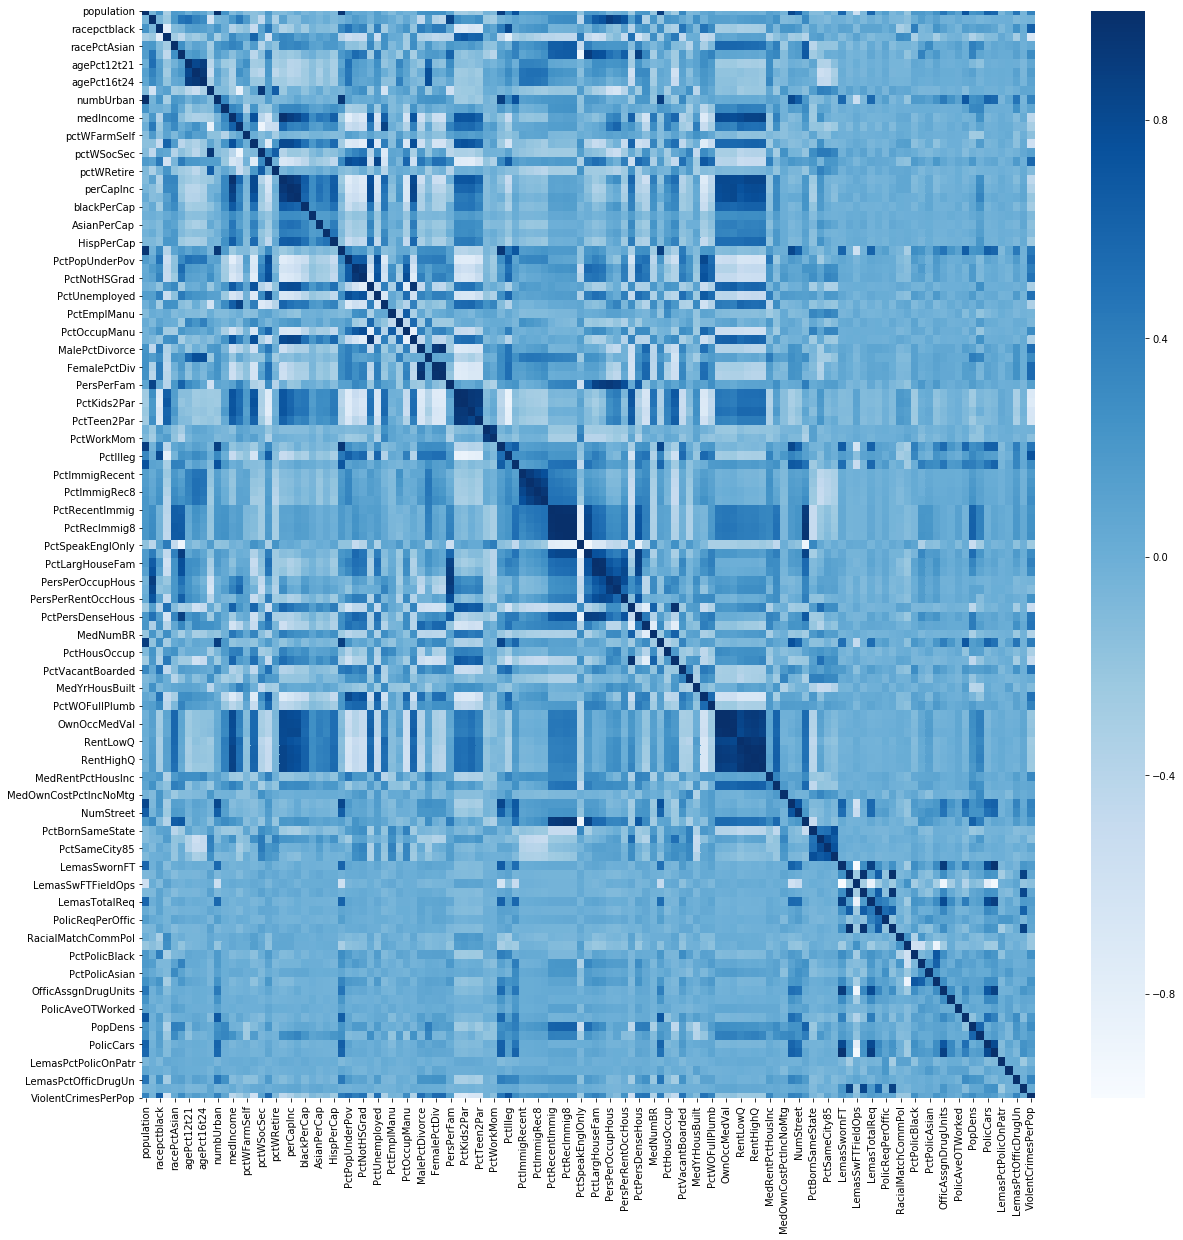

In [8]:
# Correlation heatmap
plt.figure(figsize = (20,20))
corr = communities.corr()
sns.heatmap(corr,cmap="Blues")

#### (d) Calculate the Coefficient of Variation CV for each feature, where CV = s/m , in which s is sample standard deviation and m is sample mean.

In [9]:
# Coefficient of Variation (CV)
cv = lambda x : np.std(x)/np.mean(x)
var = np.apply_along_axis(cv, axis = 0, arr = np.matrix(communities))
var

array([2.20294993, 0.3532097 , 1.41056656, 0.32370036, 1.35882134,
       1.61387296, 0.36574812, 0.29061999, 0.49503634, 0.42333552,
       2.00124163, 0.63868866, 0.579608  , 0.32762787, 0.69985456,
       0.35914986, 0.36842021, 0.6988552 , 0.3495514 , 0.52759954,
       0.54549659, 0.5074249 , 0.58932117, 0.80948203, 0.60604183,
       0.67048209, 0.47384086, 2.30439167, 0.75379109, 0.67543079,
       0.52815378, 0.57825579, 0.55599333, 0.34724014, 0.5104523 ,
       0.39812581, 0.5083338 , 0.422     , 0.39548416, 0.40371035,
       0.3591826 , 0.371375  , 0.31687526, 0.33052823, 0.3323925 ,
       0.32934323, 0.32846855, 0.33616412, 0.33263868, 2.99344555,
       0.91957222, 2.89976977, 0.6840295 , 0.58474358, 0.50478324,
       0.45555177, 1.29977426, 1.29730638, 1.28091166, 1.28371176,
       0.28860078, 1.45870069, 0.73435052, 0.75691886, 0.36682182,
       0.31932719, 0.46833631, 0.3502283 , 1.1269169 , 0.34828327,
       0.81068443, 1.9582885 , 0.26957935, 0.33745632, 1.06447

#### (e) Pick b 128c features with highest CV , and make scatter plots and box plots for them. Can you draw conclusions about significance of those features, just by the scatter plots?

In [10]:
# Pick 11 features with highest CV
cv_dict = dict(sorted(dict(zip(communities.columns,var)).items(),key = operator.itemgetter(1),reverse = True)[0:11])
significant_features = list(cv_dict.keys())
significant_features

['NumStreet',
 'NumInShelters',
 'NumIlleg',
 'NumImmig',
 'LemasPctOfficDrugUn',
 'NumUnderPov',
 'population',
 'numbUrban',
 'HousVacant',
 'LandArea',
 'racePctHisp']

<Figure size 1440x720 with 0 Axes>

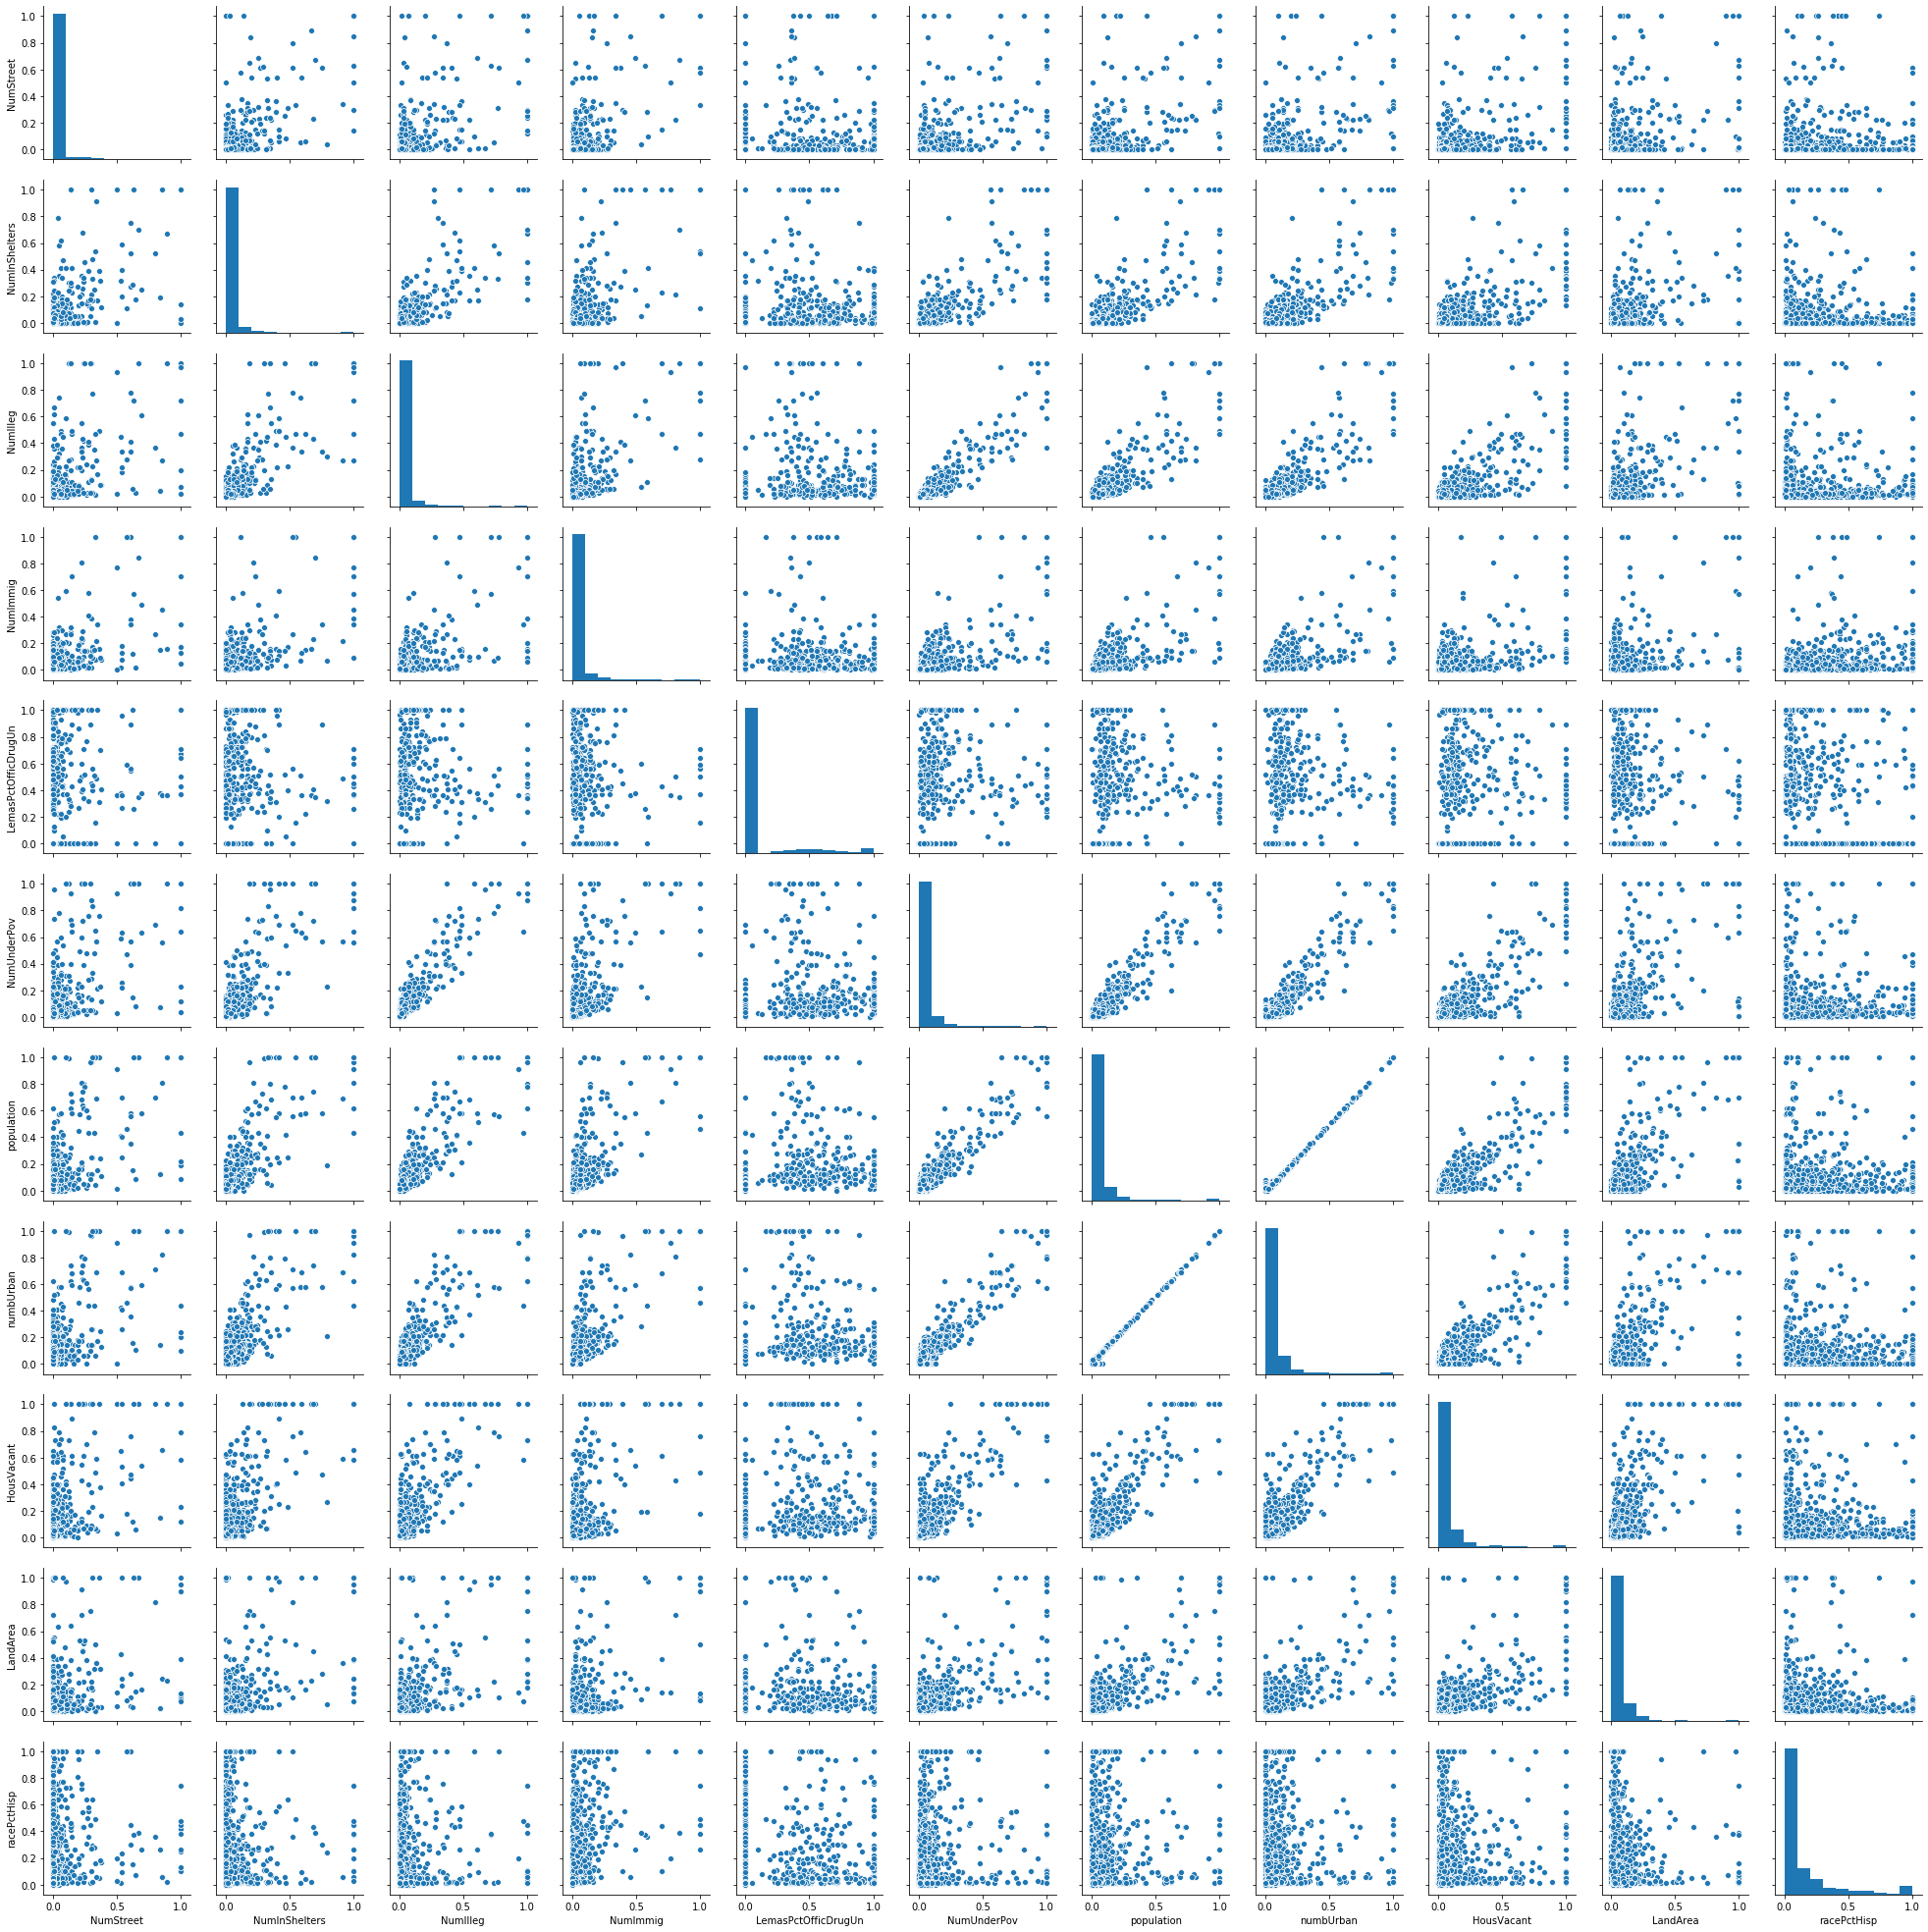

In [11]:
# Scatter plots of significant features
plt.figure(figsize = (20,10))
sns.pairplot(communities[list(cv_dict.keys())])

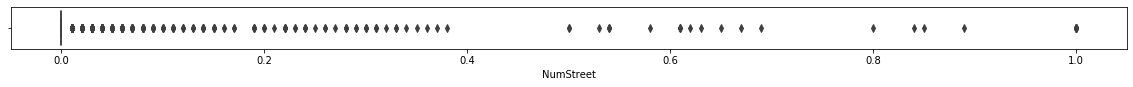

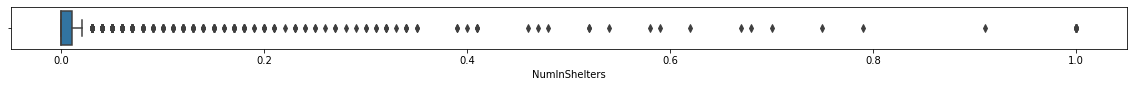

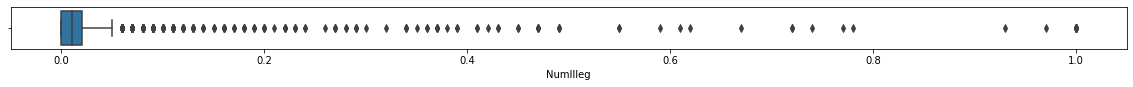

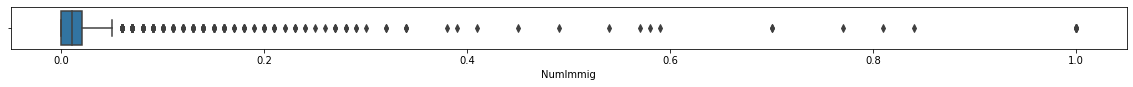

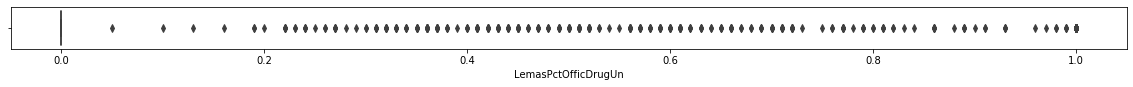

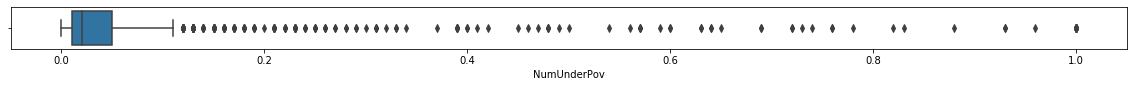

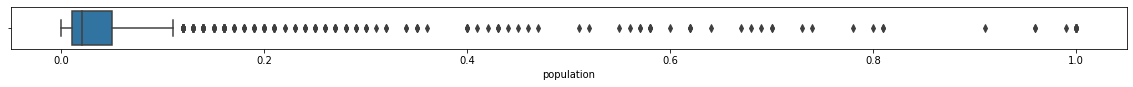

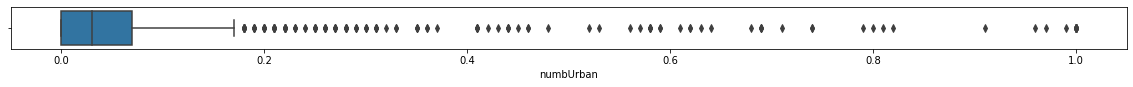

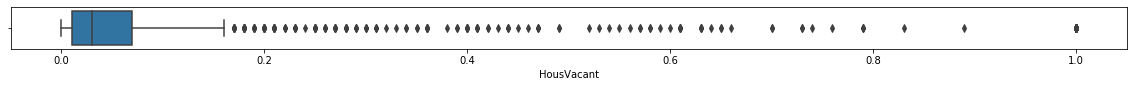

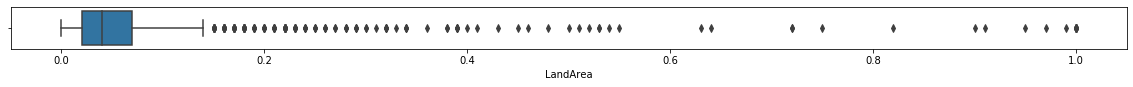

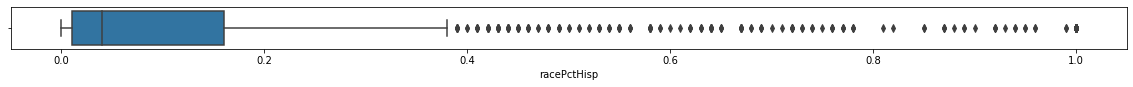

In [12]:
row = 11
col = 1
for i,v in enumerate(significant_features):
    plt.figure(figsize=(20,10))
    plt.subplot(row,col,i+1)
    sns.boxplot(communities[v])

#### (f) Fit a linear model using least squares to the training set and report the test error

In [13]:
def split_data(data):
    training = data.iloc[0:1495]
    testing = data.iloc[1495:]

    X_train = training.iloc[:,0:122]
    y_train = training.iloc[:,122]
    X_test = testing.iloc[:,0:122]
    y_test = testing.iloc[:,122]
    
    return X_train, y_train, X_test, y_test

In [14]:
X_train, y_train, X_test, y_test = split_data(communities)

linear_reg = LinearRegression()
linear_reg.fit(X_train,y_train)
y_pred = linear_reg.predict(X_test)
print("Test error :- ",metrics.mean_squared_error(y_test, y_pred)*100,"%")

Test error :-  1.815405658183456 %


#### (g) Fit a ridge regression model on the training set, with λ chosen by cross-validation. Report the test error obtained.

In [15]:
# Ridge Regression (Here lambda = alpha)
X_train, y_train, X_test, y_test = split_data(communities)

grid = {"alpha":[1e-15, 1e-10, 1e-8, 1e-4, 1e-3,1e-2, 1, 5, 10, 20]} 
ridge = Ridge()
ridge_cv = GridSearchCV(ridge, grid, cv = 5)
ridge_cv.fit(X_train,y_train)
best_alpha = ridge_cv.best_estimator_.get_params()['alpha']

refit_ridge = Ridge(alpha = best_alpha)
refit_ridge.fit(X_train, y_train)
y_pred = refit_ridge.predict(X_test)
print("Test error :- ",metrics.mean_squared_error(y_test, y_pred)*100,"%")

Test error :-  1.7497090703653038 %


In [16]:
# RidgeCV gives the same results

#### (h) Fit a LASSO model on the training set, with λ chosen by cross-validation. Report the test error obtained, along with a list of the variables selected by the model. Repeat with standardized features. Report the test error for both cases and compare them.

In [17]:
# Lasso Regression (Here lambda = alpha)
X_train, y_train, X_test, y_test = split_data(communities)

grid = {"alpha":[1e-15, 1e-10, 1e-8, 1e-4, 1e-3,1e-2, 1, 5, 10, 20]} 
lasso = Lasso()
lasso_cv = GridSearchCV(lasso, grid, cv = 5)
lasso_cv.fit(X_train,y_train)
best_alpha = lasso_cv.best_estimator_.get_params()['alpha']

refit_lasso = Lasso(alpha = best_alpha)
refit_lasso.fit(X_train, y_train)
y_pred = refit_lasso.predict(X_test)
print("Test error :- ",metrics.mean_squared_error(y_test, y_pred)*100,"%")

Test error :-  1.7784801860924848 %


In [18]:
coef = pd.Series(refit_lasso.coef_, index = X_train.columns)
coef[coef == 0]

population            -0.0
householdsize          0.0
racePctWhite          -0.0
racePctHisp            0.0
agePct16t24            0.0
numbUrban             -0.0
medIncome              0.0
medFamInc              0.0
perCapInc             -0.0
NumUnderPov           -0.0
PctNotHSGrad           0.0
PctUnemployed         -0.0
PctEmplProfServ        0.0
PctOccupMgmtProf       0.0
TotalPctDiv           -0.0
PersPerFam             0.0
PctFam2Par            -0.0
PctWorkMomYoungKids    0.0
PctImmigRecent        -0.0
PctImmigRec5          -0.0
PctImmigRec8          -0.0
PctRecentImmig        -0.0
PctRecImmig5           0.0
PctRecImmig8           0.0
PctSpeakEnglOnly      -0.0
PctLargHouseFam       -0.0
PersPerOwnOccHous     -0.0
PersPerRentOccHous    -0.0
PctHousOwnOcc          0.0
OwnOccMedVal          -0.0
OwnOccHiQuart         -0.0
RentMedian            -0.0
RentHighQ              0.0
PctBornSameState      -0.0
PctSameHouse85        -0.0
PctSameState85        -0.0
LemasSwornFT          -0.0
L

#### Lasso eliminated 45 out of 123 features 

In [19]:
# After standardizing
Xstd = StandardScaler().fit_transform(communities)
training = pd.DataFrame(Xstd).iloc[0:1495]
testing = pd.DataFrame(Xstd).iloc[1495:]

X_train = training.iloc[:,0:122]
y_train = training.iloc[:,122]
X_test = testing.iloc[:,0:122]
y_test = testing.iloc[:,122]

grid = {"alpha":[1e-15, 1e-10, 1e-8, 1e-4, 1e-3,1e-2, 1, 5, 10, 20]} 
lasso = Lasso()
lasso_cv = GridSearchCV(lasso, grid, cv = 5)
lasso_cv.fit(X_train,y_train)
best_alpha = lasso_cv.best_estimator_.get_params()['alpha']

refit_lasso = Lasso(alpha = best_alpha)
refit_lasso.fit(X_train, y_train)
y_pred = refit_lasso.predict(X_test)
print("Test error :- ",metrics.mean_squared_error(y_test, y_pred)*100,"%")

Test error :-  32.45105312958866 %


In [20]:
coef = pd.Series(refit_lasso.coef_, index = X_train.columns)
coef[coef == 0]

0     -0.0
1      0.0
3     -0.0
4     -0.0
5      0.0
      ... 
109   -0.0
113    0.0
116    0.0
117   -0.0
120    0.0
Length: 78, dtype: float64

#### After standardizing, Lasso eliminated 78 out of 123 features 

#### (i) Fit a PCR model on the training set, with M (the number of principal components) chosen by cross-validation. Report the test error obtained.

In [49]:
X_train, y_train, X_test, y_test = split_data(communities)

pca = PCA()
X_red = pca.fit_transform((X_train))

n = len(X_red)
print(n)
kf_10 = KFold( n_splits=10, shuffle=True, random_state=1)
lin_regr = LinearRegression()
mse = []

# Calculate MSE using CV for the 122 principle components, adding one component at the time.
for i in np.arange(1, 122):
    score = -1*cross_val_score(lin_regr, X_red[:,:i], y_train.ravel(), cv=kf_10, scoring='neg_mean_squared_error').mean()
    mse.append(score)

1495


In [50]:
min(mse),mse.index(min(mse))

(0.019255821147488715, 95)

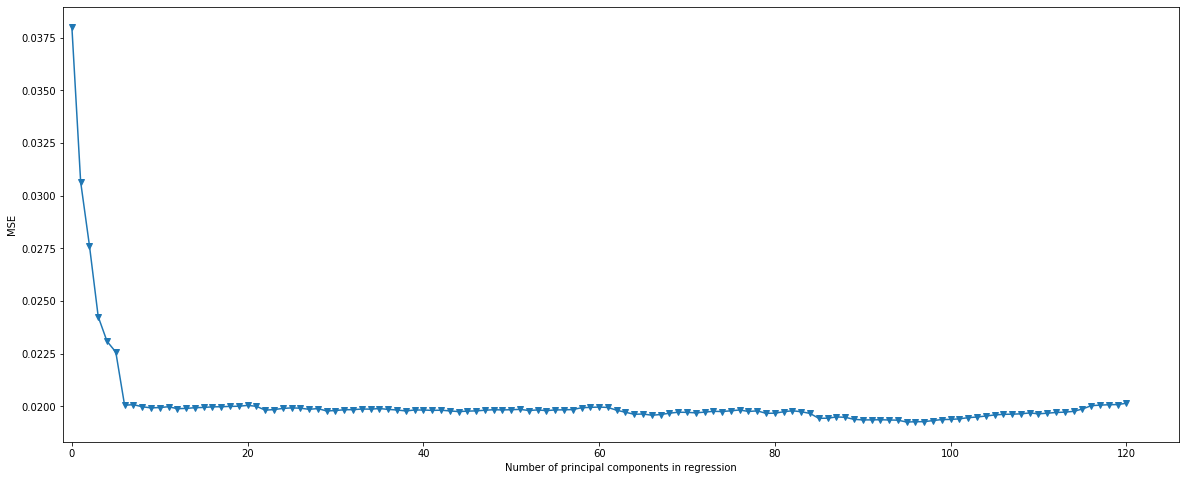

In [51]:
# Plot results    
plt.figure(figsize=(20,8))
plt.plot(mse, '-v')
plt.xlabel('Number of principal components in regression')
plt.ylabel('MSE')
plt.xlim(xmin=-1);

In [58]:
X_reduced_test = pca.transform((X_test))[:,:95]

# Train regression model on training data 
regr = LinearRegression()
regr.fit(X_red[:,:95], y_train)

# Prediction with test data
pred = regr.predict(X_reduced_test)
print("Test error using PCR :- ",metrics.mean_squared_error(y_test, pred)*100,'%')

Test error using PCR :-  1.8493684357271816 %


#### (j) In this section, we would like to fit a boosting tree to the data. As in classification trees, one can use any type of regression at each node to build a multivariate regression tree. Because the number of variables is large in this problem, one can use L 1 -penalized regression at each node. Such a tree is called L 1 penalized gradient boosting tree. You can use XGBoost to fit the model tree. Determine α (the regularization term) using cross-validation.

In [22]:
# XGBoost
X_train, y_train, X_test, y_test = split_data(communities)
dtrain = xgb.DMatrix(X_train, label = y_train)
dtest = xgb.DMatrix(X_test, label = y_test)

param_test6 = {
 'reg_alpha':[1e-4, 1e-3,1e-2, 1, 5, 10,100]
}
gsearch6 = GridSearchCV(estimator = XGBRegressor(learning_rate =0.1, n_estimators=177, max_depth=4,
 min_child_weight=6, subsample=0.8, colsample_bytree=0.8,
 objective='reg:squarederror', nthread=4, scale_pos_weight=1,seed=27), 
 param_grid = param_test6,n_jobs=4,iid=False, cv=5)
gsearch6.fit(X_train,y_train)
gsearch6.best_params_

{'reg_alpha': 5}

In [23]:
refit_xgb = XGBRegressor(learning_rate =0.1, n_estimators=177, max_depth=4,
 min_child_weight=6, subsample=0.8, colsample_bytree=0.8,
 objective='reg:squarederror', nthread=4, scale_pos_weight=1,seed=27,n_jobs=4,cv=5,reg_alpha=gsearch6.best_params_['reg_alpha']) 
refit_xgb.fit(X_train,y_train)
pred = refit_xgb.predict(X_test)
print("Random forests error :- ",metrics.mean_squared_error(y_test,pred)*100,"%")

Random forests error :-  1.6467187405934491 %


In [28]:
# Citations
# https://stackoverflow.com/questions/42754627/coefficient-of-variation-and-numpy
# http://www.science.smith.edu/~jcrouser/SDS293/labs/lab11-py.html

### Part 2 - Tree Based Methods

In [28]:
truck_train = []
truck_test = []

with open("./aps_failure_training_set.csv") as fp:
    line = fp.readline()
    truck_train.append(line[:-1])
    while line:
        line = fp.readline()
        truck_train.append(line)

with open("./aps_failure_test_set.csv") as fp:
    line = fp.readline()
    #print(line)
    truck_test.append(line[:-1])
    while line:
        line = fp.readline()
        #print(line)
        truck_test.append(line)


In [29]:
truck_train_df = pd.DataFrame([sub.replace("\n","").split(",") for sub in truck_train[20:]])
truck_train_df.columns = truck_train_df.iloc[0]
truck_train_df = truck_train_df.drop(truck_train_df.index[0])

In [30]:
truck_test_df = pd.DataFrame([sub.replace("\n","").split(",") for sub in truck_test[20:]])
truck_test_df.columns = truck_test_df.iloc[0]
truck_test_df = truck_test_df.drop(truck_test_df.index[0])

In [31]:
truck_train_df.shape, truck_test_df.shape

((60001, 171), (16001, 171))

In [32]:
truck_train_df.head()

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,ag_004,ag_005,ag_006,ag_007,ag_008,ag_009,ah_000,ai_000,aj_000,ak_000,al_000,am_0,an_000,ao_000,ap_000,aq_000,ar_000,as_000,at_000,au_000,av_000,ax_000,ay_000,ay_001,ay_002,ay_003,ay_004,ay_005,ay_006,ay_007,ay_008,ay_009,az_000,az_001,az_002,az_003,az_004,az_005,az_006,az_007,az_008,az_009,ba_000,ba_001,ba_002,ba_003,ba_004,ba_005,ba_006,ba_007,ba_008,ba_009,bb_000,bc_000,bd_000,be_000,bf_000,bg_000,bh_000,bi_000,bj_000,bk_000,bl_000,bm_000,bn_000,bo_000,bp_000,bq_000,br_000,bs_000,bt_000,bu_000,bv_000,bx_000,by_000,bz_000,ca_000,cb_000,cc_000,cd_000,ce_000,cf_000,cg_000,ch_000,ci_000,cj_000,ck_000,cl_000,cm_000,cn_000,cn_001,cn_002,cn_003,cn_004,cn_005,cn_006,cn_007,cn_008,cn_009,co_000,cp_000,cq_000,cr_000,cs_000,cs_001,cs_002,cs_003,cs_004,cs_005,cs_006,cs_007,cs_008,cs_009,ct_000,cu_000,cv_000,cx_000,cy_000,cz_000,da_000,db_000,dc_000,dd_000,de_000,df_000,dg_000,dh_000,di_000,dj_000,dk_000,dl_000,dm_000,dn_000,do_000,dp_000,dq_000,dr_000,ds_000,dt_000,du_000,dv_000,dx_000,dy_000,dz_000,ea_000,eb_000,ec_00,ed_000,ee_000,ee_001,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
1,neg,76698,na,2130706438,280,0,0,0,0,0,0,37250,1432864,3664156,1007684,25896,0,2551696,0,0,0,0,0,4933296,3655166,1766008,1132040,0,0,0,0,1012,268,0,0,0,0,0,469014,4239660,703300,755876,0,5374,2108,4114,12348,615248,5526276,2378,4,0,0,2328746,1022304,415432,287230,310246,681504,1118814,3574,0,0,6700214,0,10,108,50,2551696,97518,947550,799478,330760,353400,299160,305200,283680,na,na,na,178540,76698.08,6700214,6700214,6599892,43566,68656,54064,638360,6167850,1209600,246244,2,96,0,5245752,0,916567.68,6,1924,0,0,0,118196,1309472,3247182,1381362,98822,11208,1608,220,240,6700214,na,10476,1226,267998,521832,428776,4015854,895240,26330,118,0,532,734,4122704,51288,0,532572,0,18,5330690,4732,1126,0,0,0,0,0,0,0,0,62282,85908,32790,0,0,202710,37928,14745580,1876644,0,0,0,0,2801180,2445.8,2712,965866,1706908,1240520,493384,721044,469792,339156,157956,73224,0,0,0
2,neg,33058,na,0,na,0,0,0,0,0,0,18254,653294,1720800,516724,31642,0,1393352,0,68,0,0,0,2560898,2127150,1084598,338544,0,0,0,0,0,0,0,0,0,0,0,71510,772720,1996924,99560,0,7336,7808,13776,13086,1010074,1873902,14726,6,0,0,1378576,447166,199512,154298,137280,138668,165908,229652,87082,4708,3646660,86,454,364,350,1393352,49028,688314,392208,341420,359780,366560,na,na,na,na,na,6700,33057.51,3646660,3646660,3582034,17733.0,260120,115626,6900,2942850,1209600,0,na,na,na,2291079.36,0,643536.96,0,0,0,0,38,98644,1179502,1286736,336388,36294,5192,56,na,0,3646660,na,6160,796,164860,350066,272956,1837600,301242,9148,22,0,na,na,na,na,na,na,na,na,na,3312,522,0,0,0,0,0,0,0,0,33736,36946,5936,0,0,103330,16254,4510080,868538,0,0,0,0,3477820,2211.76,2334,664504,824154,421400,178064,293306,245416,133654,81140,97576,1500,0,0
3,neg,41040,na,228,100,0,0,0,0,0,0,1648,370592,1883374,292936,12016,0,1234132,0,0,0,0,0,2371990,2173634,300796,153698,0,0,0,0,358,110,0,0,0,0,0,0,870456,239798,1450312,0,1620,1156,1228,34250,1811606,710672,34,0,0,0,790690,672026,332340,254892,189596,135758,103552,81666,46,0,2673338,128,202,576,4,1234132,28804,160176,139730,137160,130640,na,na,na,na,na,na,28000,41040.08,2673338,2673338,2678534,15439.0,7466,22436,248240,2560566,1209600,63328,0,124,0,2322692.16,0,236099.52,0,0,0,0,0,33276,1215280,1102798,196502,10260,2422,28,0,6,2673338,na,3584,500,56362,149726,100326,1744838,488302,16682,246,0,230,292,2180528,29188,22,20346,0,0,2341048,1494,152,0,0,0,0,0,0,0,0,13876,38182,8138,0,0,65772,10534,300240,48028,0,0,0,0,1040120,1018.64,1020,262032,453378,277378,159812,423992,409564,320746,158022,95128,514,0,0
4,neg,12,0,70,66,0,10,0,0,0,318,2212,3232,1872,0,0,0,2668,0,0,0,642,3894,10184,7554,10764,1014,0,0,0,0,60,6,0,0,0,0,0,0,0,2038,5596,0,64,6,6,914,76,2478,2398,1692,0,0,6176,340,304,102,74,406,216,16,0,0,21614,2,12,0,0,2668,184,7632,3090,na,na,na,na,na,na,na,na,10580,12.69,21614,21614,21772,32,50,1994,21400,7710,120960

In [33]:
del truck_test, truck_train

### (b) Data Preparation

##### (i) Research what types of techniques are usually used for dealing with data with missing values. 5 Pick at least one of them and apply it to this data in the next steps. 

###### There are three methods for filling data with missing values
###### 1.)
###### 2.)
###### 3.)

In [34]:
# IMPUTE MISSING VALUES WITH MEAN
t = time.time()
for col in truck_train_df.columns[1:]:
    if truck_train_df[col].dtype != np.float64:
        truck_train_df[col] = truck_train_df[col].replace(to_replace = "na", value = np.NaN).astype(float)
    mean = truck_train_df[col].mean()
    truck_train_df[col] = truck_train_df[col].fillna(mean)
print((time.time()-t)/60)

0.4857823133468628


In [35]:
# IMPUTE MISSING VALUES WITH MEAN
t = time.time()
for col in truck_test_df.columns[1:]:
    if truck_test_df[col].dtype != np.float64:
        truck_test_df[col] = truck_test_df[col].replace(to_replace = "na", value = np.NaN).astype(float)
    mean = truck_test_df[col].mean()
    truck_test_df[col] = truck_test_df[col].fillna(mean)
print((time.time()-t)/60) 

0.11735531091690063


In [36]:
truck_train_df = truck_train_df[truck_train_df["class"] != '']
truck_test_df = truck_test_df[truck_test_df["class"] != '']
truck_train_df.shape, truck_test_df.shape

((60000, 171), (16000, 171))

##### (ii) For each of the 170 features, calculate the coefficient of variation CV = m s ,where s is sample standard deviation and m is sample mean

In [37]:
# Coefficient of Variation (CV)
cv = lambda x : np.std(x)/np.mean(x)
var = np.apply_along_axis(cv, axis = 0, arr = np.matrix(truck_train_df.iloc[:,1:]))
var

array([  2.45091715,   2.32838058,   2.16974844, 183.8460883 ,
        23.19074341,  18.6587656 ,  91.87779897,  34.85465962,
        17.36899866,   8.54997778,   5.40143368,   2.92706769,
         2.34490753,   2.83346048,   6.15453179,  32.98407617,
         2.30016808,  18.01253164,  43.80145737,  74.5260669 ,
         9.0742952 ,   9.05859612,   2.23877812,   2.26013028,
         3.05913881,   2.83958803,  10.83695939,  86.4161837 ,
        23.45922929,  68.15998601,   5.77873675,   3.87753603,
        37.00925391,  52.23341648,  38.80925699,  28.41330475,
        33.37443788,  12.38403755,   3.02306245,   3.28421469,
         3.77561604,  83.78536479,   9.32826675,   7.6463558 ,
        13.14158342,   7.44591379,   2.81711666,   3.00804943,
         8.78083868,  16.04744938,  22.42558271,  76.96733666,
         2.68305412,   2.60870996,   2.87873171,   2.7160934 ,
         2.61599931,   2.67985343,   3.00724764,   2.81034518,
         6.75148907,   9.32142229,   2.39229943,   6.94

##### (iii) Plot a correlation matrix for your features using pandas or any other tool.

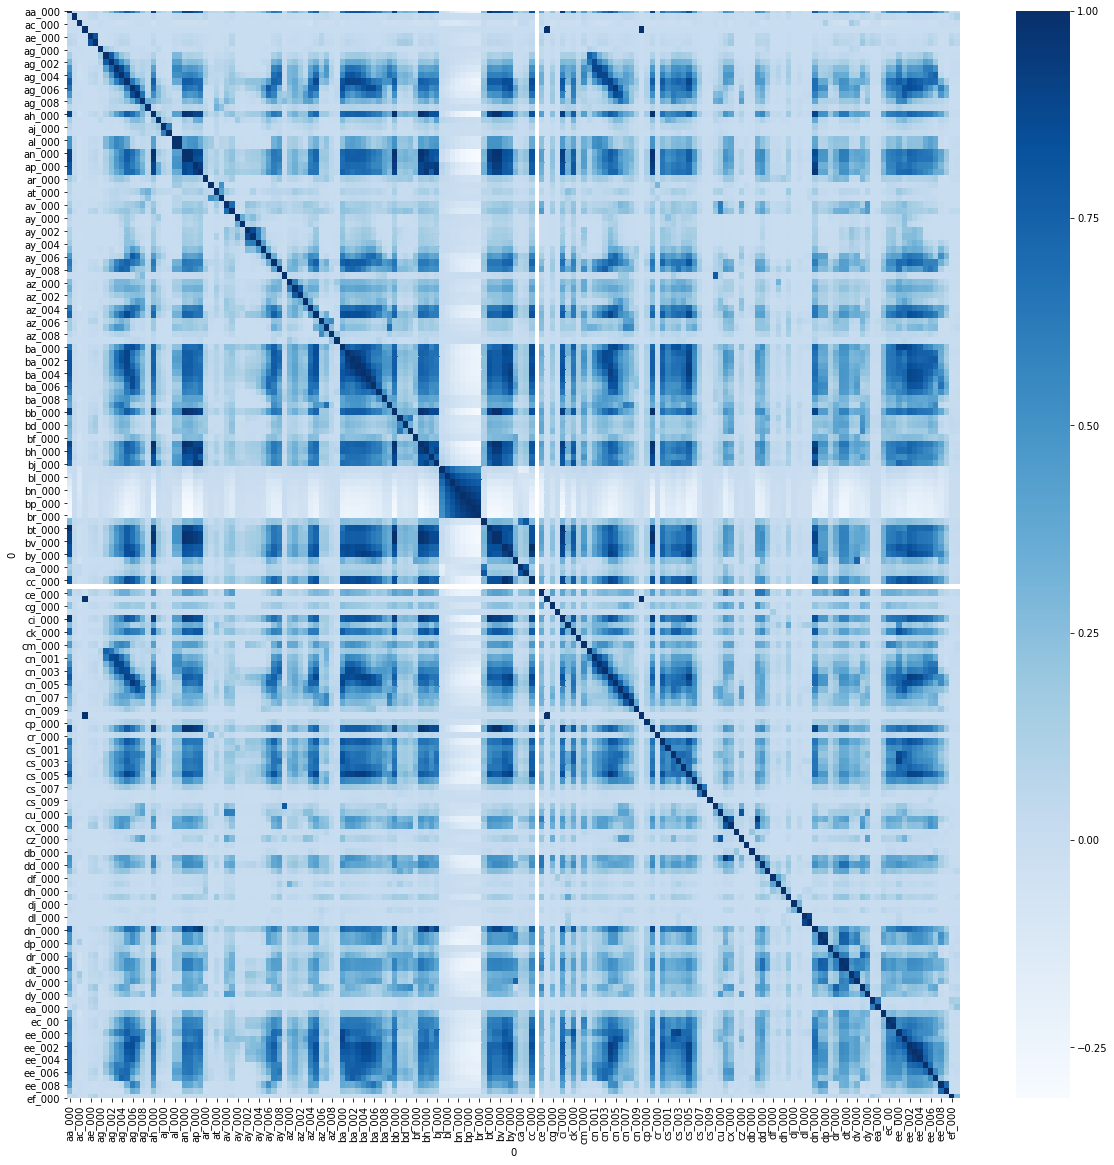

In [38]:
# Correlation heatmap
plt.figure(figsize = (20,20))
corr = truck_train_df.corr()
sns.heatmap(corr,cmap="Blues")

##### (iv) Pick b 170c features with highest CV , and make scatter plots and box plots for them, similar to those on p. 129 of ISLR. Can you draw conclusions about significance of those features, just by the scatter plots? This does not mean that you will only use those features in the following questions. We picked them only for visualization.

In [39]:
# Pick 13 features with highest CV
cv_dict = dict(sorted(dict(zip(truck_train_df.columns,var)).items(),key = operator.itemgetter(1),reverse = True)[0:13])
significant_features = list(cv_dict.keys())
significant_features

['cs_008',
 'ce_000',
 'cn_009',
 'ac_000',
 'dg_000',
 'di_000',
 'af_000',
 'ar_000',
 'ay_008',
 'az_008',
 'aj_000',
 'at_000',
 'cg_000']

<Figure size 1440x720 with 0 Axes>

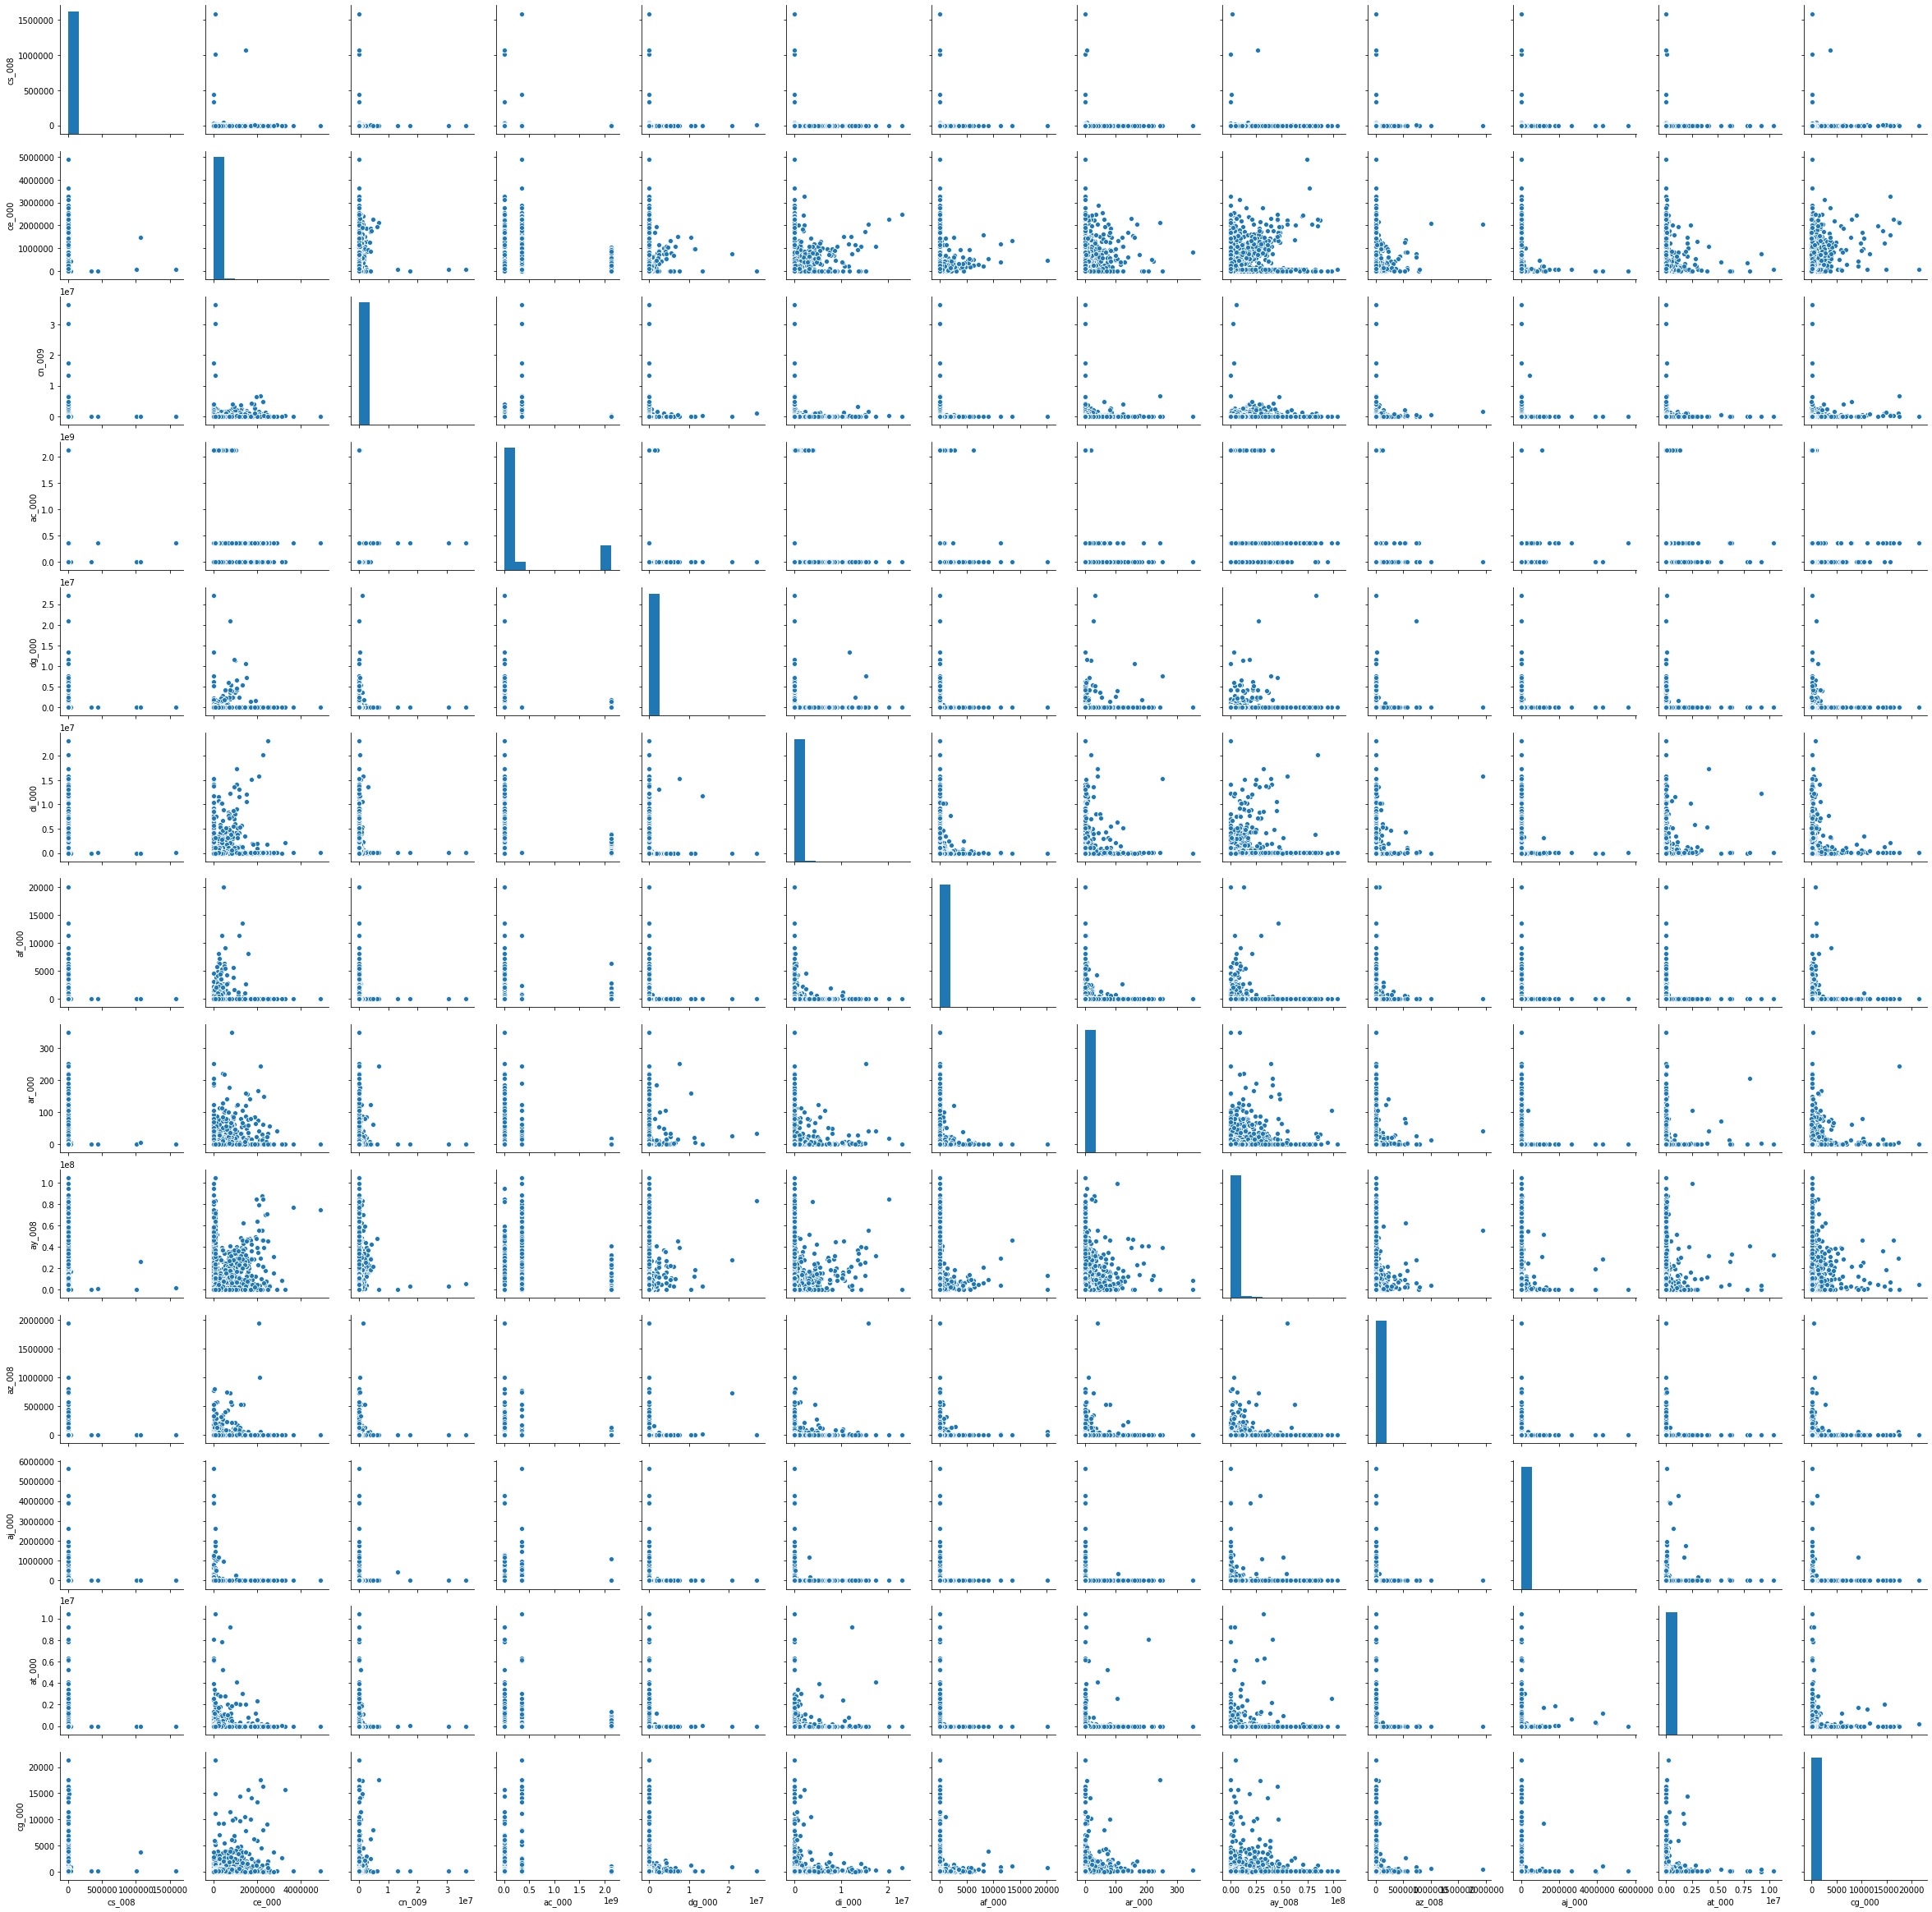

In [40]:
# Scatter plots of significant features
plt.figure(figsize = (20,10))
sns.pairplot(truck_train_df[list(cv_dict.keys())])

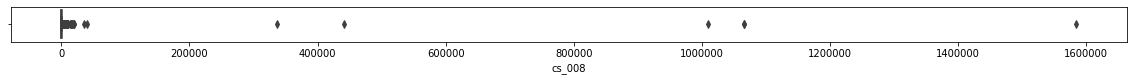

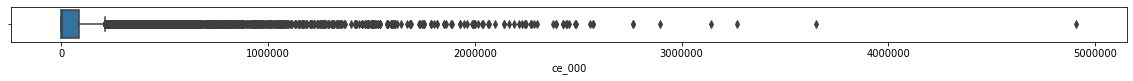

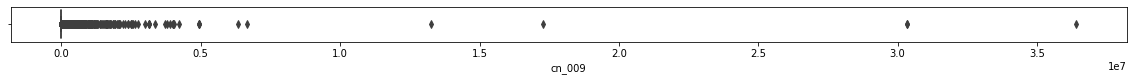

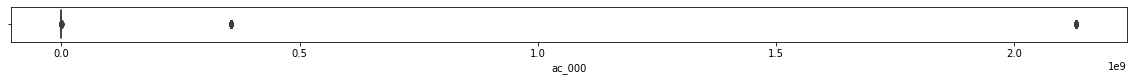

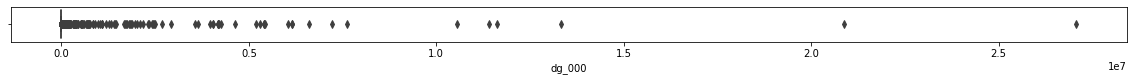

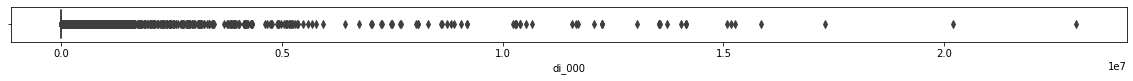

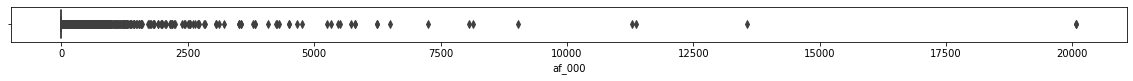

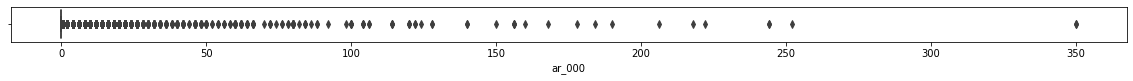

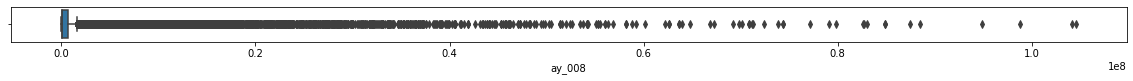

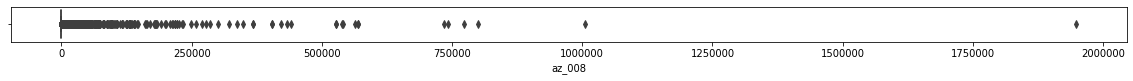

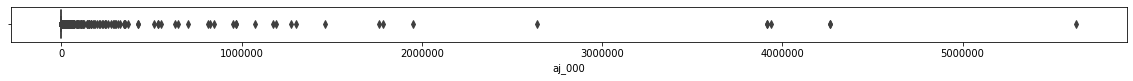

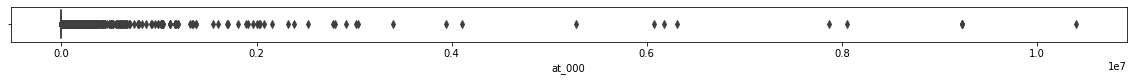

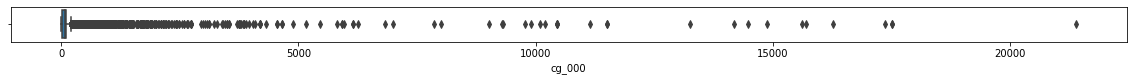

In [41]:
row = 13
col = 1
for i,v in enumerate(significant_features):
    plt.figure(figsize=(20,10))
    plt.subplot(row,col,i+1)
    sns.boxplot(truck_train_df[v])

##### (v) Determine the number of positive and negative data. Is this data set imbalanced?

In [42]:
truck_train_df["class"].value_counts()

neg    59000
pos     1000
Name: class, dtype: int64

In [43]:
truck_train_df.to_csv("./imputed_truck_train.csv",index=False)
truck_test_df.to_csv("./imputed_truck_test.csv",index=False)

#### (c) Train a random forest to classify the data set. Do NOT compensate for class imbalance in the data set. Calculate the confusion matrix, ROC, AUC, and misclassification for training and test sets and report them (You may use pROC package). Calculate Out of Bag error estimate for your random forset and compare it to the test error.

In [44]:
le = LabelEncoder()
truck_train_df['class'] = le.fit_transform(truck_train_df['class'])
truck_test_df['class'] = le.fit_transform(truck_test_df['class'])

In [45]:
truck_train_df['class'].value_counts()
# 0 - negative
# 1 - positive

0    59000
1     1000
Name: class, dtype: int64

Train Score :-  1.0
Test Score :-  0.9920625
Out of Bag Score :-  0.9940333333333333
Confusion Matrix :-  [[15608    17]
 [  110   265]]
Area under the curve :-  0.8527893333333334


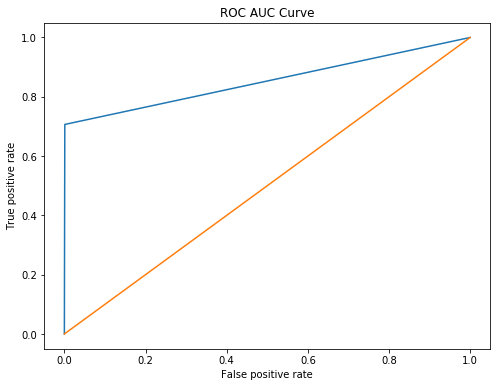

In [46]:
# Without balancing classes
clf = RandomForestClassifier(n_jobs = 2, random_state = 4, oob_score = True, n_estimators = 100)
clf.fit(truck_train_df.iloc[:,1:],truck_train_df.iloc[:,0])
y_predict = clf.predict(truck_test_df.iloc[:,1:])
print("Train Score :- ",clf.score(truck_train_df.iloc[:,1:],truck_train_df.iloc[:,0]))
print("Test Score :- ",metrics.accuracy_score(truck_test_df.iloc[:,0],y_predict))
print("Out of Bag Score :- ",clf.oob_score_)
confusion_mat = metrics.confusion_matrix(truck_test_df.iloc[:,0],y_predict)
print("Confusion Matrix :- ",confusion_mat)
fpr_5, tpr_5, _ = metrics.roc_curve(truck_test_df.iloc[:,0],y_predict)
auc_5 = metrics.roc_auc_score(truck_test_df.iloc[:,0],y_predict)
plt.figure(figsize=(8,6))
plt.plot(fpr_5, tpr_5, label='ROC curve (area = %0.2f)' % auc_5)
plt.plot([0,1],[0,1])
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC AUC Curve")
print("Area under the curve :- ",auc_5)

In [47]:
clf

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
                       max_depth=None, max_features='auto', max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=100, n_jobs=2,
                       oob_score=True, random_state=4, verbose=0,
                       warm_start=False)

#### (d) Research how class imbalance is addressed in random forests. Compensate for class imbalance in your random forest and repeat 2c. Compare the results with those of 2c.

Train Score :-  1.0
Test Score :-  0.9888125
Out of Bag Score :-  0.9940333333333333
Confusion Matrix :-  [[15615    10]
 [  169   206]]
Area under the curve :-  0.7743466666666666


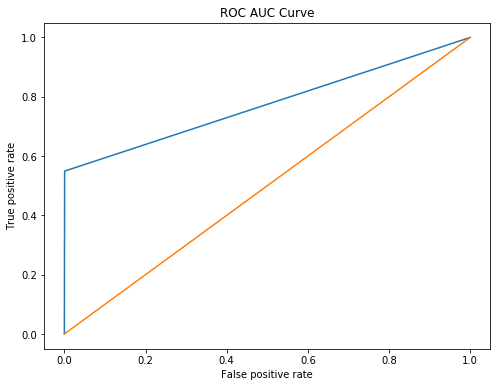

In [48]:
# With balancing classes
clf_balanced = RandomForestClassifier(n_jobs = 2, random_state = 4, oob_score = True, n_estimators = 100,class_weight = "balanced")
clf_balanced.fit(truck_train_df.iloc[:,1:],truck_train_df.iloc[:,0])
y_predict = clf_balanced.predict(truck_test_df.iloc[:,1:])
print("Train Score :- ",clf.score(truck_train_df.iloc[:,1:],truck_train_df.iloc[:,0]))
print("Test Score :- ",metrics.accuracy_score(truck_test_df.iloc[:,0],y_predict))
print("Out of Bag Score :- ",clf.oob_score_)
confusion_mat = metrics.confusion_matrix(truck_test_df.iloc[:,0],y_predict)
print("Confusion Matrix :- ",confusion_mat)
fpr_5, tpr_5, _ = metrics.roc_curve(truck_test_df.iloc[:,0],y_predict)
auc_5 = metrics.roc_auc_score(truck_test_df.iloc[:,0],y_predict)
plt.figure(figsize=(8,6))
plt.plot(fpr_5, tpr_5, label='ROC curve (area = %0.2f)' % auc_5)
plt.plot([0,1],[0,1])
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC AUC Curve")
print("Area under the curve :- ",auc_5)

#### (e) Model Trees

#### In the case of a univariate tree, only one input dimension is used at a tree split. In a multivariate tree, or model tree, at a decision node all input dimensions can be used and thus it is more general. In univariate classification trees, majority polling is used at each node to determine the split of that node as the decision rule. In model trees, a (linear) model that relies on all of the variables is used to determine the P split of that node (i.e. instead of using X j > s as the decision rule, one has j β j X j > s. as the decision rule). Alternatively, in a regression tree, instead of using average in the region associated with each node, a linear regression model is used to determine the value associated with that node. One of the methods that can be used at each node is Logistic Regression. One can use scikit learn to call Weka 7 to train Logistic Model Trees for classification. Train Logistic Model Trees for the APS data set without compensation for class imbalance. Use one of 5 fold, 10 fold, and leave-one-out cross validation methods to estimate the error of your trained model and compare it with the test error. Report the Confusion Matrix, ROC, and AUC for training and test sets.

In [ ]:
import os 
import sys 
sys.path.append("/usr/lib/jvm/java-11-openjdk-amd64/bin/") 
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64/" 
!apt-get install build-essential python3-dev 
!apt-get install python3-pil python3-pygraphviz 
!apt install openjdk-11-jdk 
!pip3 install javabridge --no-cache-dir 
!pip3 install python-weka-wrapper3 --no-cache-dir 
import weka.core.jvm as jvm 
jvm.start()  

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
uploaded = files.upload()

#### (f) Use SMOTE (Synthetic Minority Over-sampling Technique) to pre-process your data to compensate for class imbalance.  Train a Logistic Model Tree using the pre-processed data and repeat 2e. Do not forget that there is a right and a wrong way of cross validation here. Compare the uncompensated case with SMOTE.

In [49]:
from imblearn.over_sampling import SMOTE

In [50]:
sm = SMOTE(random_state=42)
X_bal,y_bal = sm.fit_resample(truck_train_df.iloc[:,1:], truck_train_df.iloc[:,0])

In [51]:
len(y_bal[y_bal==1])

59000

In [52]:
X_bal.shape

(118000, 170)